# Deformation Stress Test

A non-planar synthetic airway with **6 generations** (gen 0 = trachea … gen 5; 45° bifurcations, each child's
bifurcation plane twisted 45° about the child) is the fixed image. Each group below deforms it with a known transform to
make the moving image and hands both masks to the **C++ `AirwayEvaluation` CLI** (`--deformableEvaluation`). Nothing in
this notebook re-implements the pipeline: every score and every debug image is what the CLI wrote.

**Scores** (from the CLI's `results.csv`): tree length detected (**TLD**) and branch detection (**BD**) overall and per
ground-truth generation. Each case is also scored before registration (the CLI without `--deformableEvaluation`).

**Pictures** come from the CLI's `--overlapComparison` volume (1 = overlap, 2 = ground truth only, 3 = prediction only),
drawn as MIPs: ground truth only = green, prediction only = magenta, overlap = white.

**Parameters**: `PARAMETERS` (configuration cell) is passed to every CLI call; it starts at the CLI defaults.

**Debug volumes**: every case directory under `OUTPUT_DIR` holds the moving mask plus everything the CLI can write
(overlap / tree-length comparisons, registered prediction, skeletons, branch and generation labels, branch origins,
`results.csv`, and the CLI log), ready to open in Slicer.

Groups: identity (sanity baseline) → translation → rotation → translation + rotation → translation + rotation + shear →
nonrigid (B-spline) at increasing magnitude → breath hold (the nonterminal tree deformed the way a second CT breath hold
moves it, terminal branches carried rigidly).

In [1]:
import os
import re
import sys
import time

sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import AirwayEvaluationCLI as cli  # puts the custom ITK build on sys.path
import Deformations as D
from SyntheticAirway import make_synthetic_airway

import itk

## Configuration

In [2]:
IMAGE_SIZE = 300
GENERATIONS = 6  # gen 0 (trachea) .. gen 5
BIFURCATION_ANGLE = 45.0  # degrees between each child and its parent
PLANE_TWIST = 45.0  # degrees each child's bifurcation plane is rotated about the child (0 = planar tree)
SEED = 0

# what counts as a ~perfect reconstruction
PERFECT_TLD = 0.95  # tree length detected (fraction)
PERFECT_GEN_BD = 1.00  # branch detection (fraction) required in every generation

# CLI hyperparameters (AirwayEvaluationCLI.PARAMETER_FLAGS); start from the CLI defaults
PARAMETERS = dict(cli.DEFAULT_PARAMETERS)

CLI_EXECUTABLE = cli.DEFAULT_EXECUTABLE
OUTPUT_DIR = "cli_outputs"  # one directory per case with the moving mask and every CLI output

print(CLI_EXECUTABLE, "built", time.ctime(os.path.getmtime(CLI_EXECUTABLE)))

/IPLlinux/raid0/homes/jkitzmann/Research/PCCTAirwaySegmentation/build/bin/AirwayEvaluation built Tue Sep 29 16:06:47 2026


## Fixed airway

63 branches (0 pruned for collisions), 22421 voxels, center [111.6 128.  128. ] -> cli_outputs/phantoms/non-planar.nii.gz


,branches,radius,length
generation,,,
0,1,6.00,60.00
1,2,4.50,33.75
2,4,3.38,25.31
3,8,2.53,18.98
4,16,1.90,14.24
5,32,1.42,10.68


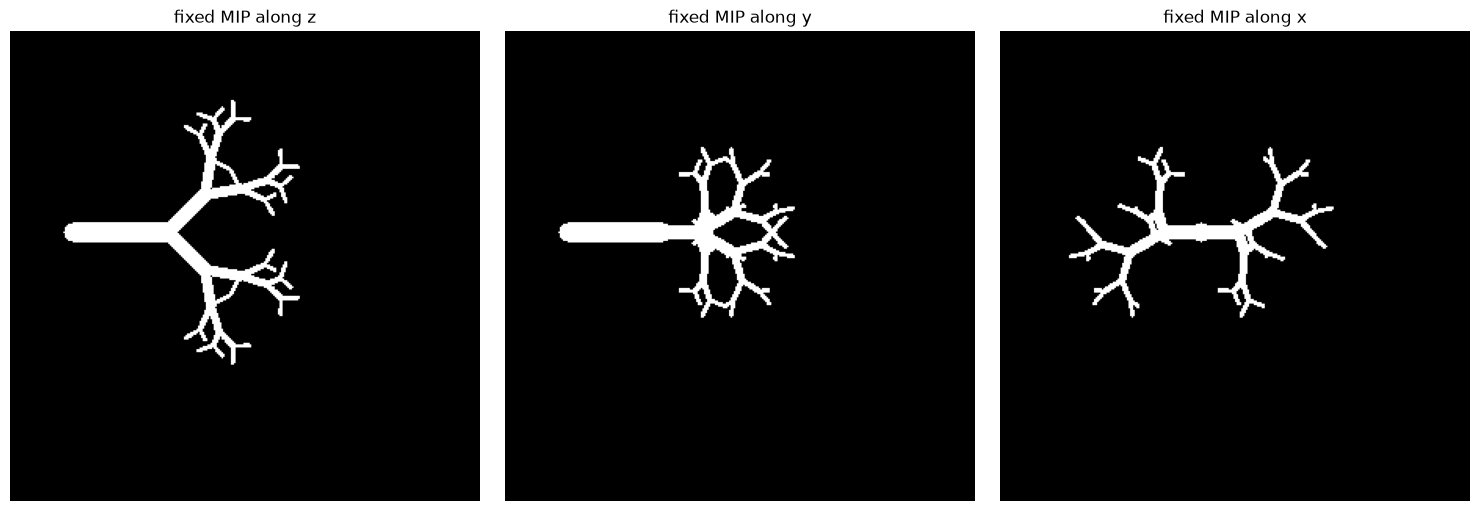

In [3]:
def show_mip(array, title="", cmap="gray"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, axis, name in zip(axes, range(3), ["along z", "along y", "along x"]):
        ax.imshow(array.max(axis=axis), cmap=cmap)
        ax.set_title(f"{title} MIP {name}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def set_phantom(tree, name):
    """Make tree the fixed airway every helper below deforms and scores against."""
    global PHANTOM, airway, fixed_array, FIXED_PATH
    PHANTOM = D.Phantom(tree, name, seed=SEED)
    airway, fixed_array = tree, PHANTOM.array

    # the CLI reads the ground truth from disk
    FIXED_PATH = os.path.join(OUTPUT_DIR, "phantoms", f"{name}.nii.gz")
    os.makedirs(os.path.dirname(FIXED_PATH), exist_ok=True)
    PHANTOM.write(FIXED_PATH)


GEN_IDS = list(range(GENERATIONS))
base_airway = make_synthetic_airway(
    image_size=IMAGE_SIZE,
    generations=GENERATIONS,
    bifurcation_angle=BIFURCATION_ANGLE,
    plane_twist=PLANE_TWIST,
)
set_phantom(base_airway, "non-planar")

summary = pd.DataFrame([
    {"generation": b["generation"], "radius": b["radius"], "length": b["length"]} for b in airway.branches
]).groupby("generation").agg(branches=("radius", "size"), radius=("radius", "first"), length=("length", "mean"))
print(f"{len(airway.branches)} branches ({len(airway.pruned)} pruned for collisions), "
      f"{fixed_array.sum()} voxels, center {np.round(PHANTOM.center, 1)} -> {FIXED_PATH}")
display(summary.round(2))
show_mip(fixed_array, "fixed")

## Helpers: deformations, CLI runner, display

Deformations come from `Deformations.py` (shared with `DeformationSweep.py`). Every transform is the resampling transform,
i.e. `moving(x) = fixed(T(x))`; masks are warped with linear interpolation and re-thresholded at 0.5 so shear and nonrigid
warps stay smooth, and `moving/fixed vox` shows how much the warp itself changed the airway (gen 5 is only ~1.4 voxels in
radius). Breath holds are rebuilt from the phantom's centerlines instead.

Group tables: `TLD` / `BD` before registration and after the CLI's deformable registration, plus branches detected per
generation (`g0 det` … `g5 det`, from the ground truth skeleton labeling).

In [4]:
# ----------------------------------------------------------------------------
# Deformations of the current phantom (Deformations.py)
# ----------------------------------------------------------------------------

translation = D.translation
BreathHold = D.BreathHold


def rigid(angles_deg, offset=(0, 0, 0)):
    return D.rigid(PHANTOM, angles_deg, offset)


def affine(angles_deg, offset, shear):
    return D.affine(PHANTOM, angles_deg, offset, shear)


def bspline(peak_displacement, mesh_size=6):
    return D.bspline(PHANTOM, peak_displacement, mesh_size, seed=SEED)


# ----------------------------------------------------------------------------
# Scoring (all from the CLI)
# ----------------------------------------------------------------------------

def scores(run, suffix=""):
    """TLD / BD (fractions) and per-generation detection from a CLIRun."""
    if not run.ok:
        return {}
    row = {
        "TLD" + suffix: run.tree_length_detected / 100,
        "BD" + suffix: run.branch_detection / 100,
    }
    if suffix:
        return row
    row["branches"] = run.branches
    row["DSC"] = run.metrics["DSC"] / 100
    for g in GEN_IDS:
        detection = run.generations.get(g)
        row[f"g{g} BD"] = detection.branch_detection / 100 if detection else np.nan
        row[f"g{g} det"] = f"{detection.branches_detected}/{detection.total_branches}" if detection else "–"
    return row


def verdict(row):
    """PASS, or the first generation whose branch detection drops (else FAIL (TLD))."""
    if row.get("status", "ok") != "ok":
        return "ERROR"
    missed = [g for g in GEN_IDS if pd.notna(row.get(f"g{g} BD")) and row[f"g{g} BD"] < PERFECT_GEN_BD]
    if row["TLD"] >= PERFECT_TLD and not missed:
        return "PASS"
    return f"FAIL (gen {missed[0]}+)" if missed else "FAIL (TLD)"


# ----------------------------------------------------------------------------
# Runner
# ----------------------------------------------------------------------------

RESULTS = {}  # (group, case) -> row; re-running a cell overwrites its rows
RUNS = {}  # (group, case) -> (before CLIRun, registered CLIRun)


def slug(text):
    return re.sub(r"[^A-Za-z0-9.=+-]+", "_", str(text)).strip("_")


def run_case(group, case, deformation, parameters, results=None, runs=None, root=OUTPUT_DIR):
    """Deform the fixed airway (ITK transform, or a BreathHold), then score the moving mask with the
    CLI as given and with --deformableEvaluation. All inputs/outputs land in root/<group>/<case>/."""
    results = RESULTS if results is None else results
    runs = RUNS if runs is None else runs
    case_dir = os.path.join(root, slug(group), slug(case))
    os.makedirs(case_dir, exist_ok=True)

    moving, mean_disp, peak_disp = D.deform(PHANTOM, deformation)
    moving_path = os.path.join(case_dir, "moving.nii.gz")
    itk.imwrite(moving, moving_path, compression=True)

    start = time.time()
    before = cli.run_cli(moving_path, FIXED_PATH, os.path.join(case_dir, "before"), deformable=False,
                         parameters=PARAMETERS, volumes=("overlapComparison",), executable=CLI_EXECUTABLE)
    registered = cli.run_cli(moving_path, FIXED_PATH, os.path.join(case_dir, "registered"), deformable=True,
                             parameters=PARAMETERS, executable=CLI_EXECUTABLE)

    row = {
        "group": group,
        "case": case,
        "parameters": parameters,
        "mean disp": mean_disp,
        "peak disp": peak_disp,
        "moving/fixed vox": (itk.array_view_from_image(moving) > 0).sum() / fixed_array.sum(),
        **scores(before, " before"),
        "status": "ok" if registered.ok else "error: " + registered.error[:120],
        **scores(registered),
        "seconds": time.time() - start,
        "outputs": case_dir,
    }
    row["verdict"] = verdict(row)
    results[(group, case)] = row
    runs[(group, case)] = (before, registered)

    if registered.ok:
        print(f"{case:>28}: TLD {row['TLD before']:.1%} -> {row['TLD']:.1%}  "
              f"BD {row['BD before']:.1%} -> {row['BD']:.1%} ({row['branches']})  "
              f"{row['verdict']}  ({row['seconds']:.0f}s)")
    else:
        print(f"{case:>28}: {row['status']}")
    return row


# ----------------------------------------------------------------------------
# Display
# ----------------------------------------------------------------------------

GEN_DET_COLUMNS = [f"g{g} det" for g in GEN_IDS]
GROUP_COLUMNS = ["parameters", "peak disp", "TLD before", "TLD", "BD before", "BD"] + GEN_DET_COLUMNS + ["verdict"]
PERCENT_COLUMNS = ["TLD before", "TLD", "BD before", "BD", "DSC"]


def overlap_mip(run, axis=0):
    """RGB MIP of the CLI's overlapComparison: GT only green, prediction only magenta, overlap white."""
    volume = run.volume("overlapComparison") if run is not None and run.ok else None
    if volume is None:
        return None
    labels = itk.array_view_from_image(volume)
    overlap = (labels == cli.OVERLAP).max(axis=axis)
    truth_only = (labels == cli.FALSE_NEGATIVE).max(axis=axis)
    prediction_only = (labels == cli.FALSE_POSITIVE).max(axis=axis)
    magenta = overlap | prediction_only
    return np.stack([magenta, overlap | truth_only, magenta], axis=-1).astype(float)


def percent(value):
    return "–" if pd.isna(value) else f"{value:.1%}"


def show_group(group):
    keys = [k for k in RESULTS if k[0] == group]
    fig, axes = plt.subplots(len(keys), 3, figsize=(11, 3.3 * len(keys)), squeeze=False)
    for ax_row, key in zip(axes, keys):
        before, registered = RUNS[key]
        row = RESULTS[key]
        panels = [
            (overlap_mip(before, 0), f"before (MIP z)\nTLD {percent(row.get('TLD before'))}  BD {percent(row.get('BD before'))}"),
            (overlap_mip(registered, 0), f"registered (MIP z)\nTLD {percent(row.get('TLD'))}  BD {percent(row.get('BD'))}"),
            (overlap_mip(registered, 1), f"registered (MIP y)\n{row['verdict'] if row['status'] == 'ok' else row['status'][:45]}"),
        ]
        for ax, (image, title) in zip(ax_row, panels):
            if image is not None:
                ax.imshow(image)
            ax.set_title(title, fontsize=9)
            ax.axis("off")
        ax_row[0].text(-0.05, 0.5, key[1], transform=ax_row[0].transAxes,
                       rotation=90, ha="right", va="center", fontsize=10)
    fig.suptitle(f"{group}: CLI overlapComparison — ground truth only = green, prediction only = magenta, "
                 f"overlap = white", y=1.0)
    plt.tight_layout()
    plt.show()

    table = pd.DataFrame([RESULTS[k] for k in keys]).set_index("case")
    display(table.reindex(columns=GROUP_COLUMNS).style.format(precision=2, na_rep="–")
            .format("{:.1%}", subset=["TLD before", "TLD", "BD before", "BD"], na_rep="–")
            .map(highlight_verdict, subset=["verdict"]))


def run_group(group, cases):
    """cases: list of (case name, transform or BreathHold, parameter description)."""
    for key in [k for k in RESULTS if k[0] == group]:
        RESULTS.pop(key)
        RUNS.pop(key)
    for case, deformation, parameters in cases:
        run_case(group, case, deformation, parameters)
    show_group(group)


def highlight_verdict(value):
    if value == "PASS":
        return "background-color: #c8e6c9; color: #1b5e20"
    if isinstance(value, str) and value.startswith(("FAIL", "ERROR")):
        return "background-color: #ffcdd2; color: #b71c1c"
    return ""


def highlight_below(value, threshold):
    return "color: #b71c1c; font-weight: bold" if pd.notna(value) and value < threshold else ""


def highlight_detection(value):
    if not isinstance(value, str) or "/" not in value:
        return ""
    found, total = value.split("/")
    return "" if found == total else "color: #b71c1c; font-weight: bold"

## 0. Identity (baseline)
No deformation, which gives the pipeline's best-case score on this phantom.

                    identity: TLD 100.0% -> 100.0%  BD 100.0% -> 100.0% (63/63)  PASS  (6s)


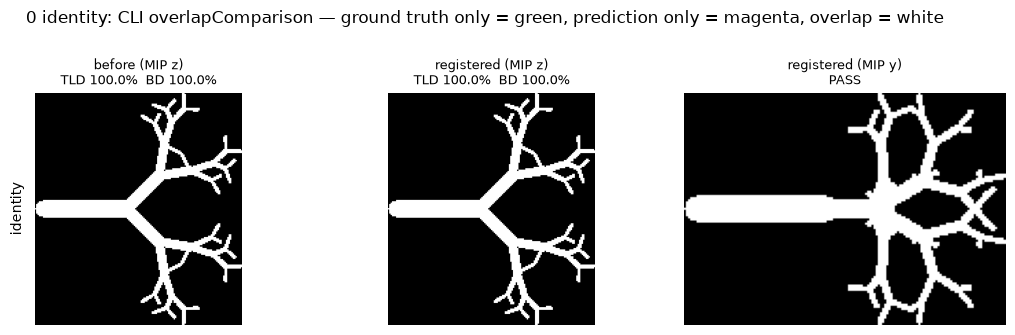

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
identity,none,0.00,100.0%,100.0%,100.0%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS


In [5]:
run_group("0 identity", [
    ("identity", translation((0, 0, 0)), "none"),
])

## 1. Translation
Offsets in voxels (ITK x, y, z).

                 t=(2, 0, 0): TLD 71.9% -> 100.0%  BD 68.2% -> 100.0% (63/63)  PASS  (6s)


                 t=(0, 5, 0): TLD 27.6% -> 100.0%  BD 15.9% -> 100.0% (63/63)  PASS  (6s)


                 t=(5, 5, 5): TLD 3.1% -> 100.0%  BD 1.6% -> 100.0% (63/63)  PASS  (6s)


              t=(10, -10, 5): TLD 0.9% -> 100.0%  BD 0.0% -> 100.0% (63/63)  PASS  (6s)


             t=(20, 15, -10): TLD 0.0% -> 100.0%  BD 0.0% -> 100.0% (63/63)  PASS  (6s)


             t=(30, -25, 20): TLD 0.4% -> 100.0%  BD 0.0% -> 100.0% (63/63)  PASS  (6s)


             t=(45, 30, -30): TLD 0.0% -> 98.7%  BD 0.0% -> 100.0% (63/63)  PASS  (6s)


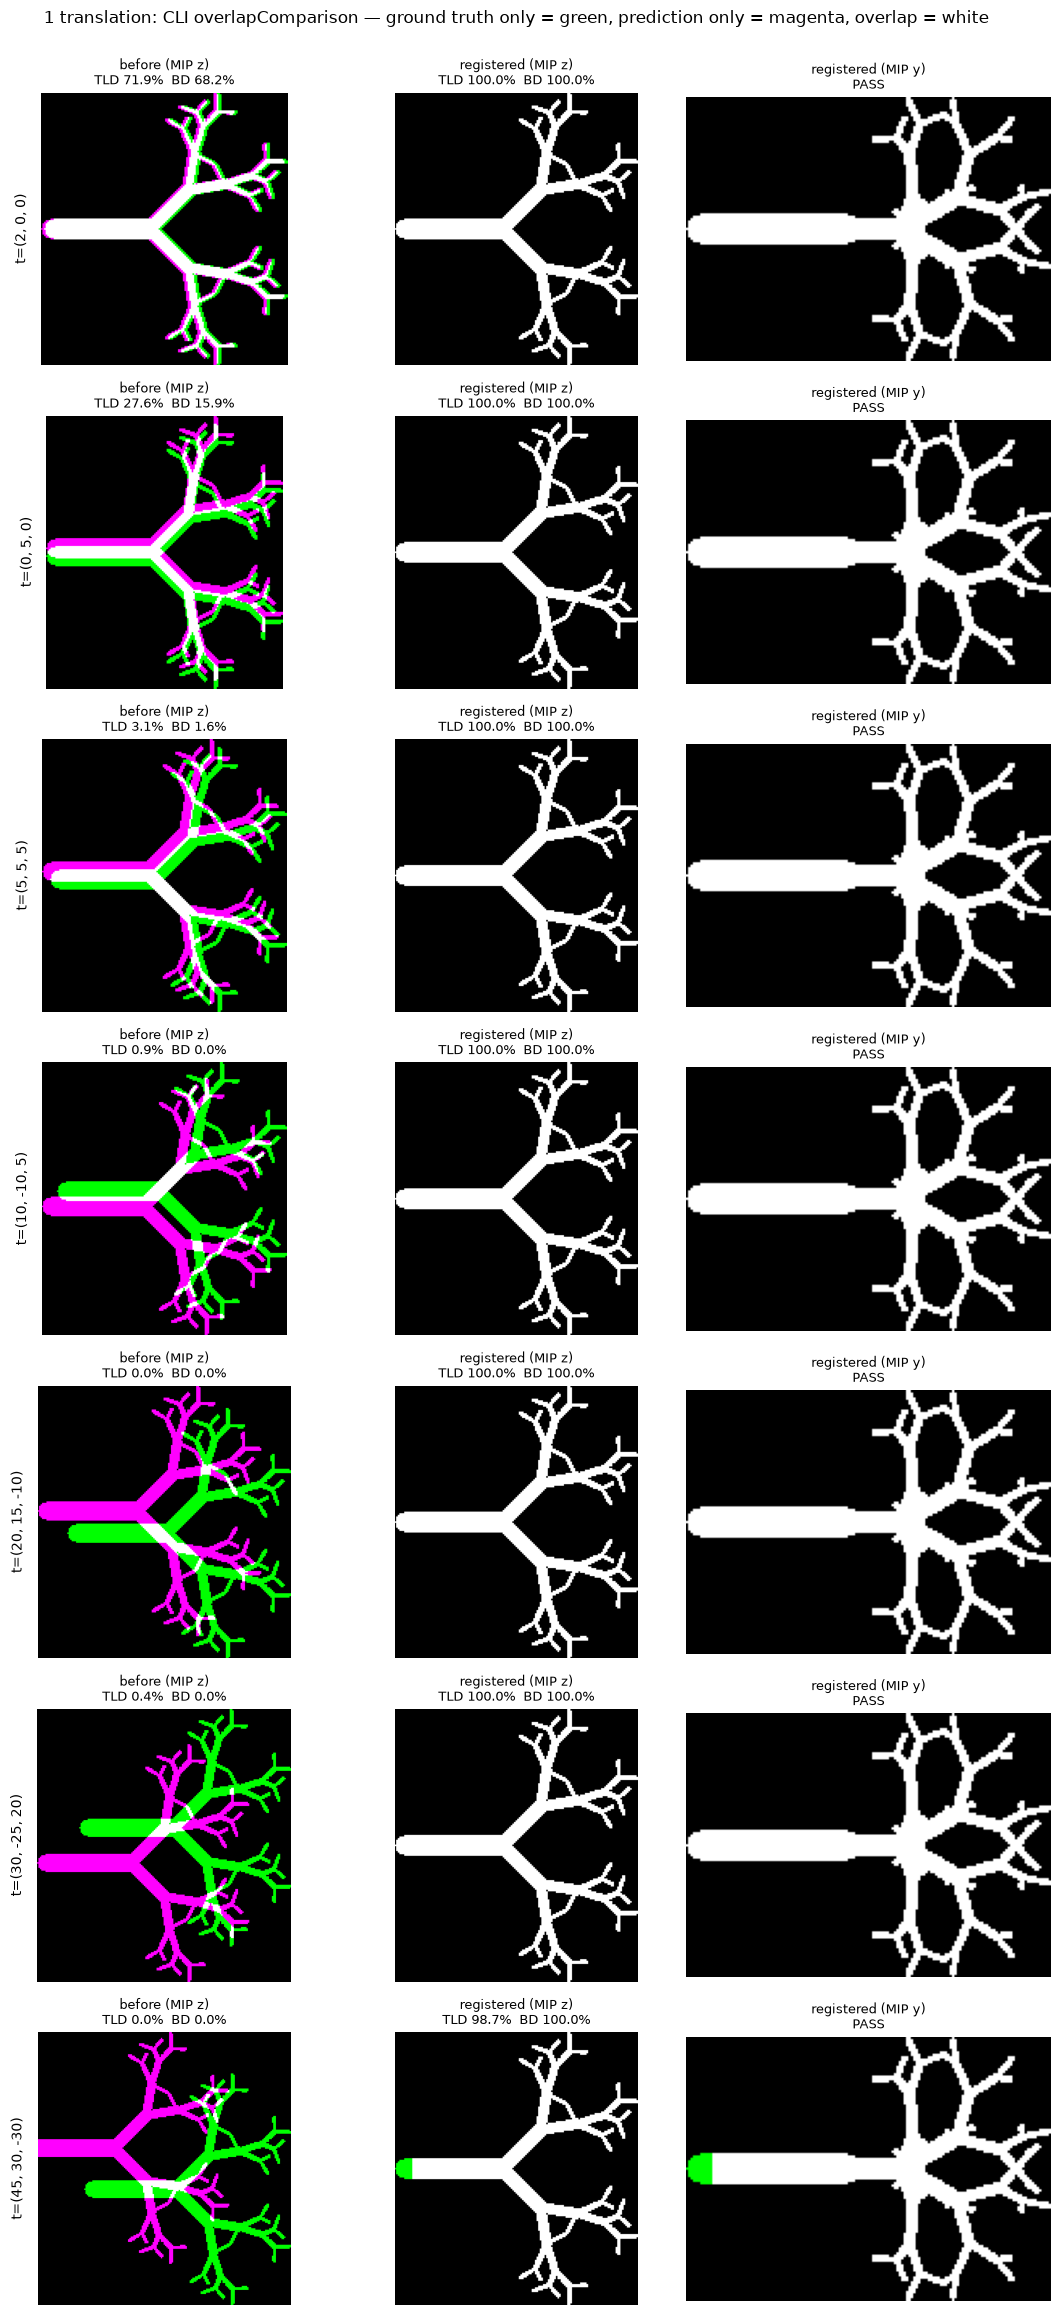

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
"t=(2, 0, 0)",|t|=2.0,2.00,71.9%,100.0%,68.2%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"t=(0, 5, 0)",|t|=5.0,5.00,27.6%,100.0%,15.9%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"t=(5, 5, 5)",|t|=8.7,8.66,3.1%,100.0%,1.6%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"t=(10, -10, 5)",|t|=15.0,15.00,0.9%,100.0%,0.0%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"t=(20, 15, -10)",|t|=26.9,26.93,0.0%,100.0%,0.0%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"t=(30, -25, 20)",|t|=43.9,43.87,0.4%,100.0%,0.0%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"t=(45, 30, -30)",|t|=61.8,61.85,0.0%,98.7%,0.0%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS


In [6]:
translations = [(2, 0, 0), (0, 5, 0), (5, 5, 5), (10, -10, 5), (20, 15, -10), (30, -25, 20), (45, 30, -30)]

run_group("1 translation", [
    (f"t={t}", translation(t), f"|t|={np.linalg.norm(t):.1f}")
    for t in translations
])

## 2. Rotation
Euler angles in degrees about x, y, z, centered on the airway centroid.

                 r=(5, 0, 0): TLD 33.2% -> 96.7%  BD 20.6% -> 100.0% (63/63)  PASS  (7s)


                r=(0, 10, 0): TLD 17.4% -> 96.1%  BD 6.3% -> 100.0% (63/63)  PASS  (7s)


                r=(0, 0, 15): TLD 6.2% -> 92.7%  BD 3.2% -> 96.8% (61/63)  FAIL (gen 4+)  (7s)


              r=(10, 10, 10): TLD 8.2% -> 94.1%  BD 4.8% -> 98.4% (62/63)  FAIL (gen 4+)  (7s)


             r=(20, -15, 10): TLD 6.2% -> 92.8%  BD 3.2% -> 100.0% (63/63)  FAIL (TLD)  (8s)


             r=(30, 20, -25): TLD 3.1% -> 90.8%  BD 0.0% -> 96.8% (61/63)  FAIL (gen 4+)  (8s)


                r=(45, 0, 0): TLD 9.7% -> 89.6%  BD 1.6% -> 98.4% (62/63)  FAIL (gen 4+)  (8s)


                r=(0, 0, 60): error: Deformable evaluation needs at least 4 paired landmarks for the thin-plate spline, found 3


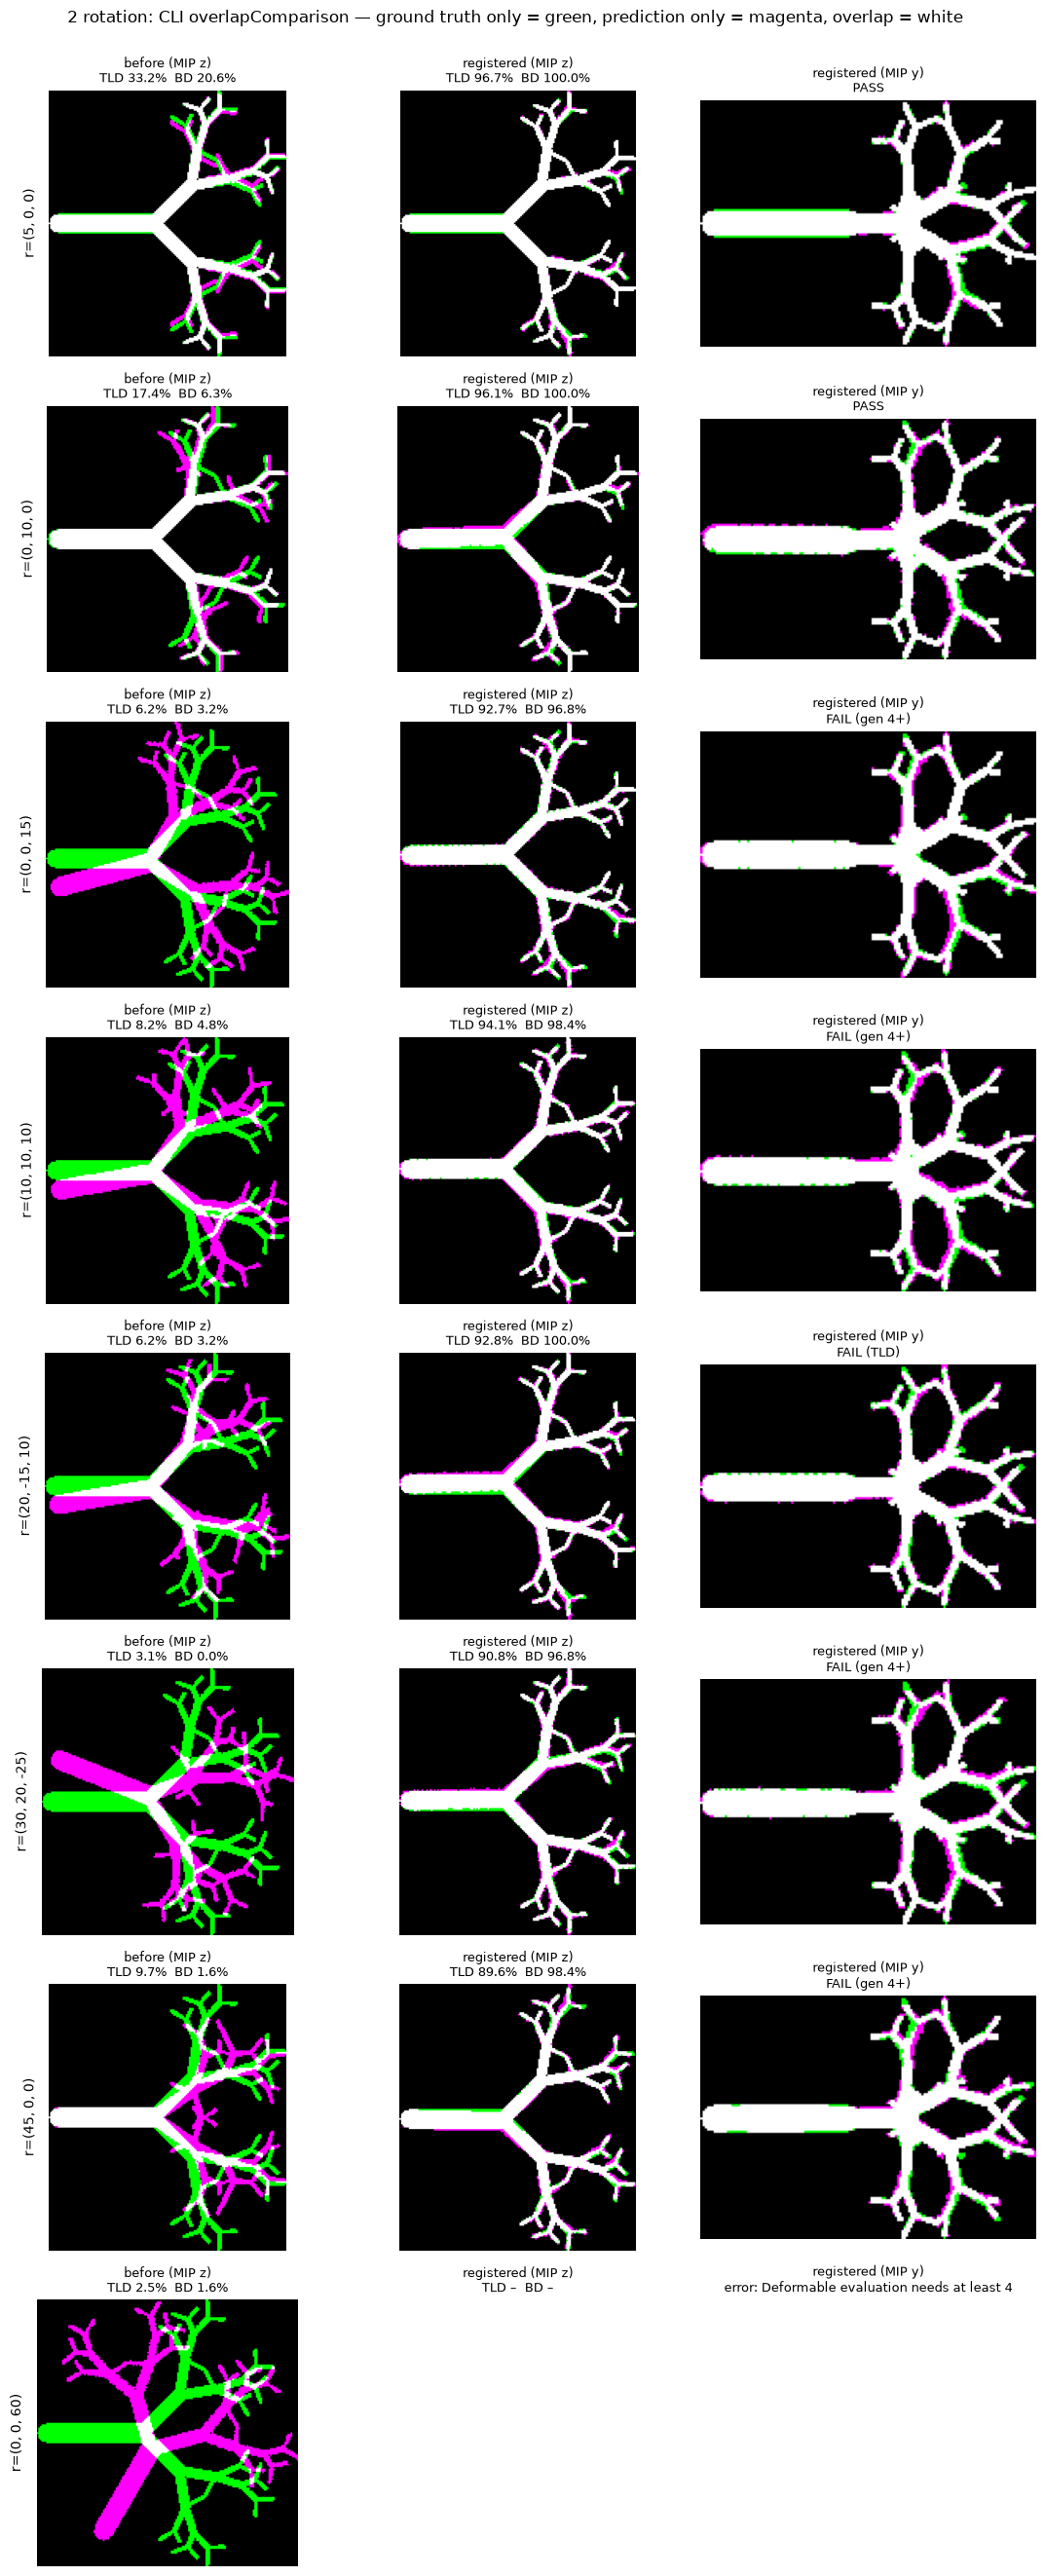

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
"r=(5, 0, 0)","angles=(5, 0, 0)",7.46,33.2%,96.7%,20.6%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"r=(0, 10, 0)","angles=(0, 10, 0)",13.54,17.4%,96.1%,6.3%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
"r=(0, 0, 15)","angles=(0, 0, 15)",23.32,6.2%,92.7%,3.2%,96.8%,1/1,2/2,4/4,8/8,15/16,31/32,FAIL (gen 4+)
"r=(10, 10, 10)","angles=(10, 10, 10)",26.55,8.2%,94.1%,4.8%,98.4%,1/1,2/2,4/4,8/8,15/16,32/32,FAIL (gen 4+)
"r=(20, -15, 10)","angles=(20, -15, 10)",39.33,6.2%,92.8%,3.2%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,FAIL (TLD)
"r=(30, 20, -25)","angles=(30, 20, -25)",61.68,3.1%,90.8%,0.0%,96.8%,1/1,2/2,4/4,8/8,15/16,31/32,FAIL (gen 4+)
"r=(45, 0, 0)","angles=(45, 0, 0)",65.45,9.7%,89.6%,1.6%,98.4%,1/1,2/2,4/4,8/8,15/16,32/32,FAIL (gen 4+)
"r=(0, 0, 60)","angles=(0, 0, 60)",89.32,2.5%,–,1.6%,–,–,–,–,–,–,–,ERROR


In [7]:
rotations = [(5, 0, 0), (0, 10, 0), (0, 0, 15), (10, 10, 10), (20, -15, 10), (30, 20, -25), (45, 0, 0), (0, 0, 60)]

run_group("2 rotation", [
    (f"r={r}", rigid(r), f"angles={r}")
    for r in rotations
])

## 3. Translation + rotation

    r=(5, 5, 0) t=(3, -3, 2): TLD 18.9% -> 94.4%  BD 11.1% -> 100.0% (63/63)  FAIL (TLD)  (7s)


  r=(10, -5, 5) t=(8, 6, -4): TLD 4.2% -> 92.2%  BD 3.2% -> 100.0% (63/63)  FAIL (TLD)  (8s)


r=(15, 10, -10) t=(15, -10, 8): TLD 0.4% -> 92.4%  BD 0.0% -> 96.8% (61/63)  FAIL (gen 4+)  (7s)


r=(25, -20, 15) t=(20, 20, -15): TLD 1.4% -> 93.4%  BD 0.0% -> 96.8% (61/63)  FAIL (gen 5+)  (7s)


r=(35, 25, -20) t=(30, -25, 20): TLD 0.2% -> 90.9%  BD 0.0% -> 96.8% (61/63)  FAIL (gen 3+)  (7s)


r=(45, -30, 30) t=(40, 30, -25): TLD 1.2% -> 84.6%  BD 1.6% -> 90.5% (57/63)  FAIL (gen 3+)  (8s)


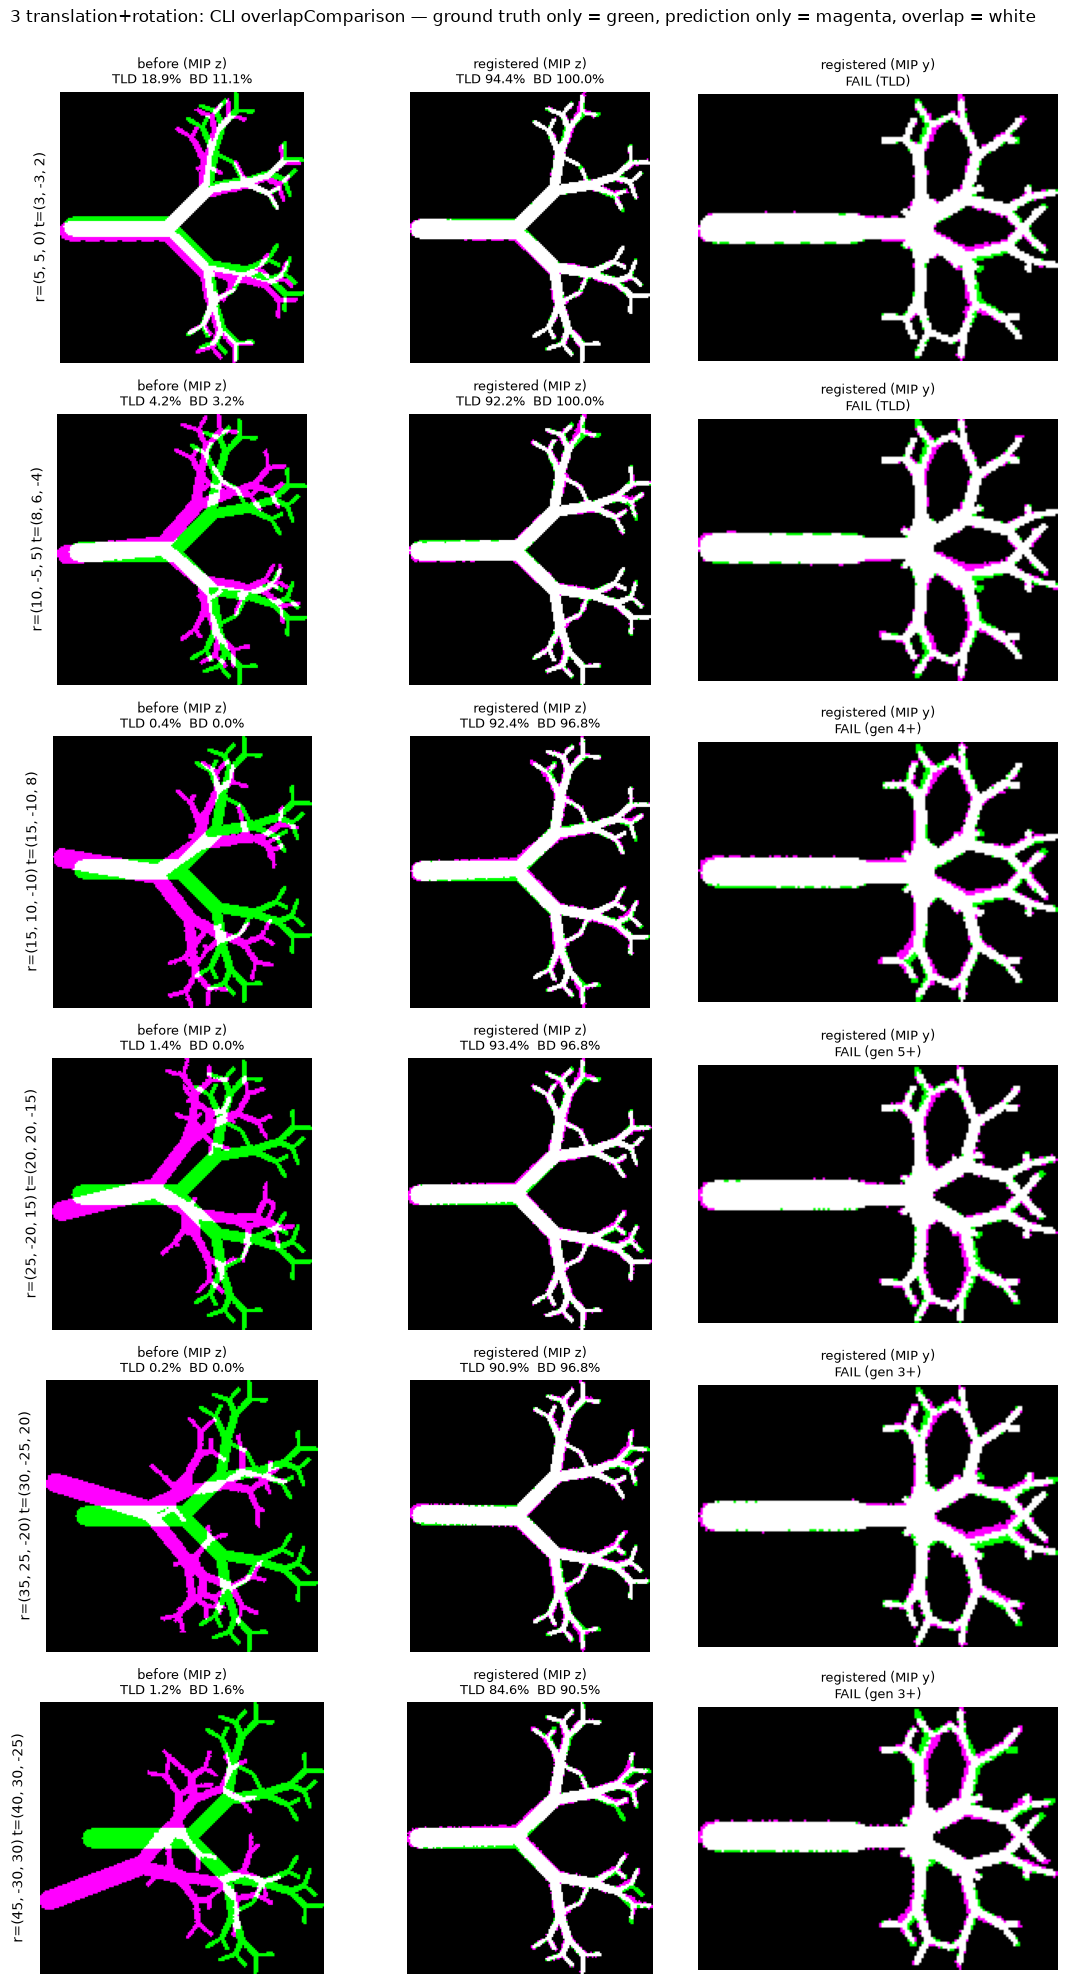

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
"r=(5, 5, 0) t=(3, -3, 2)","angles=(5, 5, 0) t=(3, -3, 2)",11.07,18.9%,94.4%,11.1%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,FAIL (TLD)
"r=(10, -5, 5) t=(8, 6, -4)","angles=(10, -5, 5) t=(8, 6, -4)",24.43,4.2%,92.2%,3.2%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,FAIL (TLD)
"r=(15, 10, -10) t=(15, -10, 8)","angles=(15, 10, -10) t=(15, -10, 8)",42.05,0.4%,92.4%,0.0%,96.8%,1/1,2/2,4/4,8/8,15/16,31/32,FAIL (gen 4+)
"r=(25, -20, 15) t=(20, 20, -15)","angles=(25, -20, 15) t=(20, 20, -15)",67.11,1.4%,93.4%,0.0%,96.8%,1/1,2/2,4/4,8/8,16/16,30/32,FAIL (gen 5+)
"r=(35, 25, -20) t=(30, -25, 20)","angles=(35, 25, -20) t=(30, -25, 20)",92.03,0.2%,90.9%,0.0%,96.8%,1/1,2/2,4/4,7/8,16/16,31/32,FAIL (gen 3+)
"r=(45, -30, 30) t=(40, 30, -25)","angles=(45, -30, 30) t=(40, 30, -25)",119.89,1.2%,84.6%,1.6%,90.5%,1/1,2/2,4/4,7/8,14/16,29/32,FAIL (gen 3+)


In [8]:
rigid_cases = [
    ((5, 5, 0), (3, -3, 2)),
    ((10, -5, 5), (8, 6, -4)),
    ((15, 10, -10), (15, -10, 8)),
    ((25, -20, 15), (20, 20, -15)),
    ((35, 25, -20), (30, -25, 20)),
    ((45, -30, 30), (40, 30, -25)),
]

run_group("3 translation+rotation", [
    (f"r={r} t={t}", rigid(r, t), f"angles={r} t={t}")
    for r, t in rigid_cases
])

## 4. Translation + rotation + shear
Shear is the (xy, xz, yz) off-diagonal of the shear matrix, applied before the rotation.

r=(5, 0, 5) t=(3, -3, 2) s=(0.02, 0.0, 0.0): TLD 16.3% -> 94.0%  BD 7.9% -> 98.4% (62/63)  FAIL (gen 4+)  (7s)


r=(10, -5, 5) t=(8, 6, -4) s=(0.05, 0.02, 0.0): TLD 3.1% -> 91.0%  BD 1.6% -> 100.0% (63/63)  FAIL (TLD)  (8s)


r=(10, 10, -10) t=(10, -8, 6) s=(0.1, 0.05, 0.05): TLD 2.0% -> 90.9%  BD 1.6% -> 95.2% (60/63)  FAIL (gen 4+)  (8s)


r=(15, -10, 10) t=(15, 10, -10) s=(0.15, 0.1, 0.05): TLD 1.2% -> 88.0%  BD 0.0% -> 92.1% (58/63)  FAIL (gen 4+)  (8s)


r=(20, 15, -15) t=(20, -15, 10) s=(0.25, 0.15, 0.1): TLD 0.7% -> 78.4%  BD 0.0% -> 82.5% (52/63)  FAIL (gen 4+)  (8s)


r=(30, -20, 20) t=(25, 20, -15) s=(0.35, 0.2, 0.15): TLD 1.4% -> 43.5%  BD 0.0% -> 46.0% (29/63)  FAIL (gen 0+)  (8s)


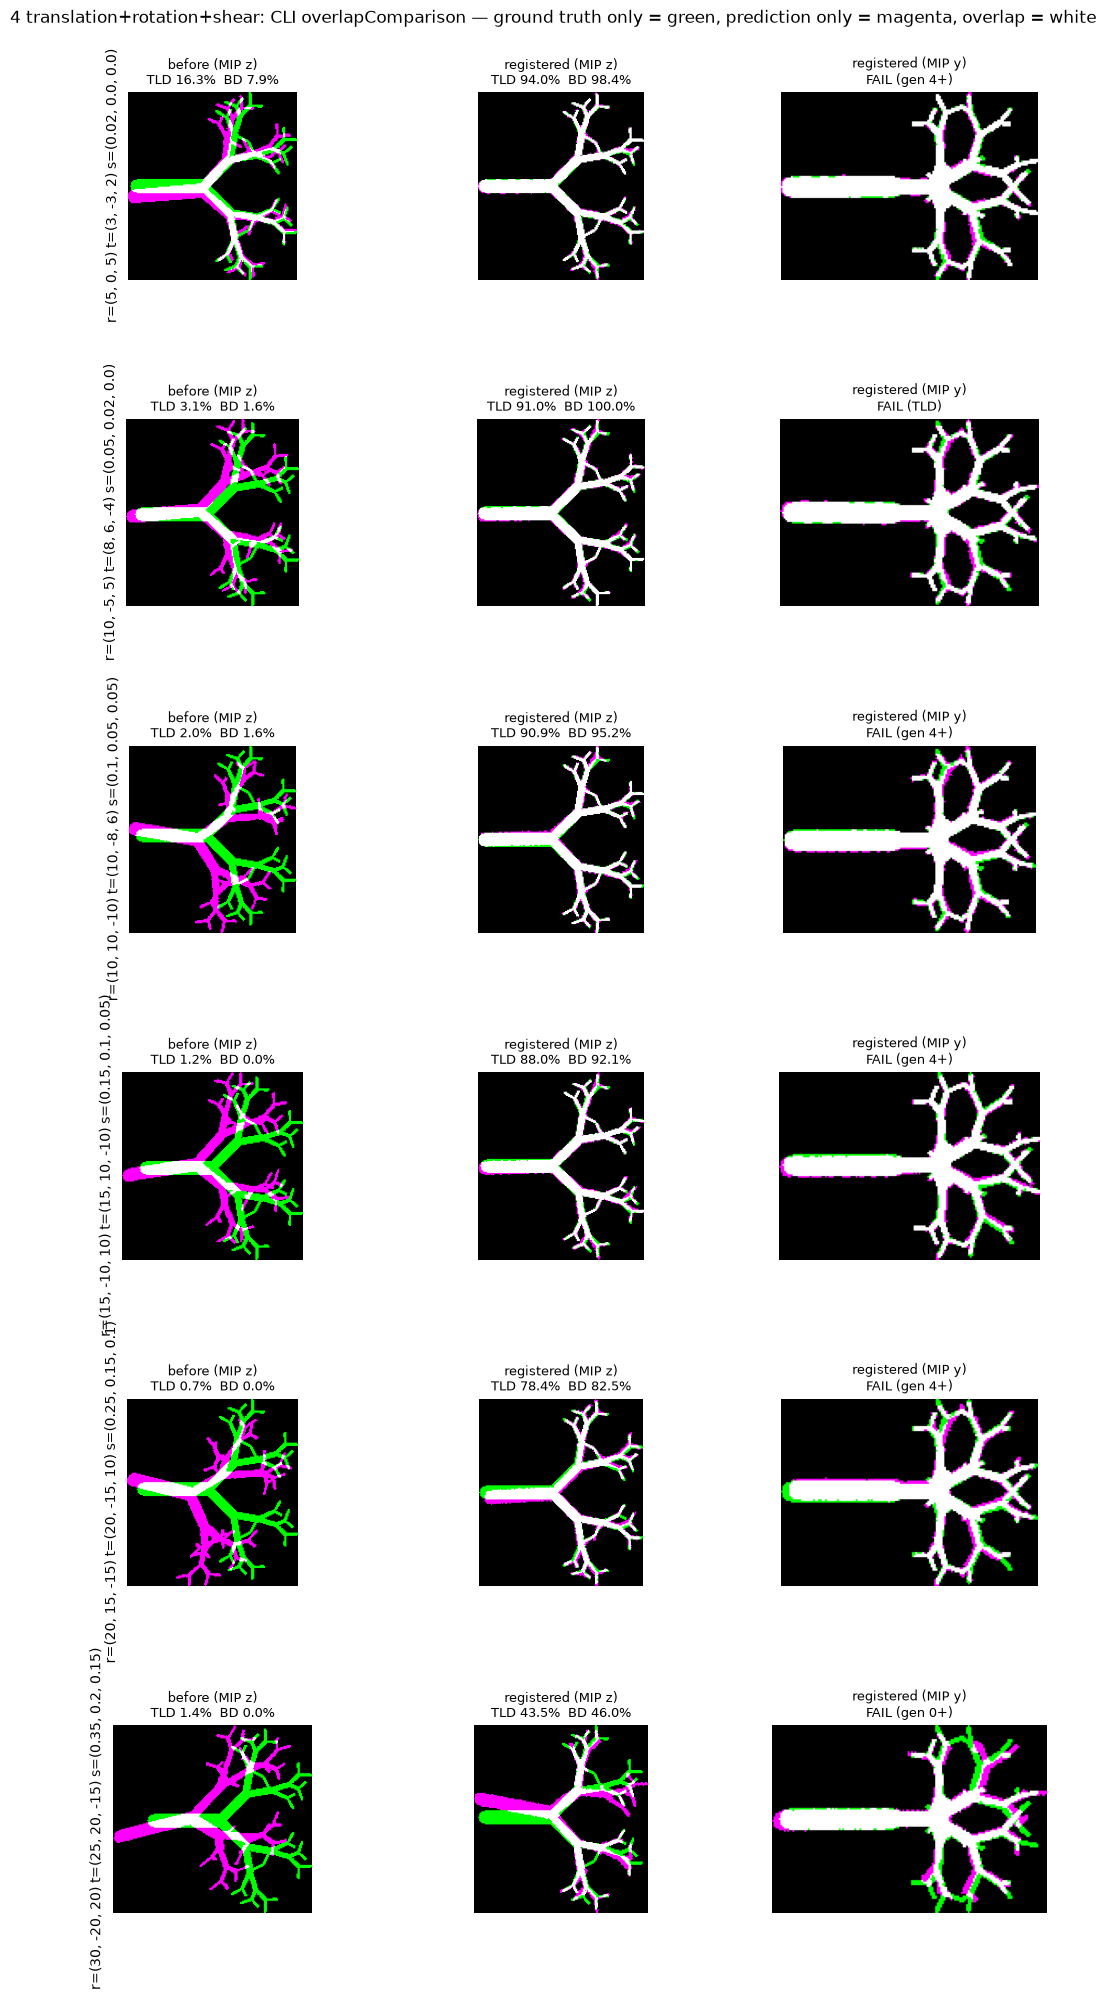

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
"r=(5, 0, 5) t=(3, -3, 2) s=(0.02, 0.0, 0.0)","angles=(5, 0, 5) t=(3, -3, 2) shear=(0.02, 0.0, 0.0)",10.67,16.3%,94.0%,7.9%,98.4%,1/1,2/2,4/4,8/8,15/16,32/32,FAIL (gen 4+)
"r=(10, -5, 5) t=(8, 6, -4) s=(0.05, 0.02, 0.0)","angles=(10, -5, 5) t=(8, 6, -4) shear=(0.05, 0.02, 0.0)",22.19,3.1%,91.0%,1.6%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,FAIL (TLD)
"r=(10, 10, -10) t=(10, -8, 6) s=(0.1, 0.05, 0.05)","angles=(10, 10, -10) t=(10, -8, 6) shear=(0.1, 0.05, 0.05)",38.62,2.0%,90.9%,1.6%,95.2%,1/1,2/2,4/4,8/8,15/16,30/32,FAIL (gen 4+)
"r=(15, -10, 10) t=(15, 10, -10) s=(0.15, 0.1, 0.05)","angles=(15, -10, 10) t=(15, 10, -10) shear=(0.15, 0.1, 0.05)",37.18,1.2%,88.0%,0.0%,92.1%,1/1,2/2,4/4,8/8,14/16,29/32,FAIL (gen 4+)
"r=(20, 15, -15) t=(20, -15, 10) s=(0.25, 0.15, 0.1)","angles=(20, 15, -15) t=(20, -15, 10) shear=(0.25, 0.15, 0.1)",72.34,0.7%,78.4%,0.0%,82.5%,1/1,2/2,4/4,8/8,8/16,29/32,FAIL (gen 4+)
"r=(30, -20, 20) t=(25, 20, -15) s=(0.35, 0.2, 0.15)","angles=(30, -20, 20) t=(25, 20, -15) shear=(0.35, 0.2, 0.15)",70.35,1.4%,43.5%,0.0%,46.0%,0/1,2/2,4/4,6/8,5/16,12/32,FAIL (gen 0+)


In [9]:
affine_cases = [
    ((5, 0, 5), (3, -3, 2), (0.02, 0.0, 0.0)),
    ((10, -5, 5), (8, 6, -4), (0.05, 0.02, 0.0)),
    ((10, 10, -10), (10, -8, 6), (0.10, 0.05, 0.05)),
    ((15, -10, 10), (15, 10, -10), (0.15, 0.10, 0.05)),
    ((20, 15, -15), (20, -15, 10), (0.25, 0.15, 0.10)),
    ((30, -20, 20), (25, 20, -15), (0.35, 0.20, 0.15)),
]

run_group("4 translation+rotation+shear", [
    (f"r={r} t={t} s={s}", affine(r, t, s), f"angles={r} t={t} shear={s}")
    for r, t, s in affine_cases
])

## 5. Nonrigid (B-spline) at increasing magnitude
Random smooth B-spline warp (control spacing ≈ 50 voxels, same random field for every case) rescaled so the **peak
displacement of any airway voxel** is the given number of voxels. Branch lengths run from 30 voxels (trachea) to ~7
(gen 5), so the larger magnitudes bend and stretch the distal generations substantially.

                      peak=1: TLD 98.0% -> 95.7%  BD 100.0% -> 98.4% (62/63)  FAIL (gen 5+)  (6s)


                      peak=2: TLD 90.4% -> 91.4%  BD 88.9% -> 100.0% (63/63)  FAIL (TLD)  (7s)


                      peak=4: TLD 68.1% -> 93.4%  BD 55.6% -> 96.8% (61/63)  FAIL (gen 5+)  (7s)


                      peak=6: TLD 49.3% -> 90.9%  BD 36.5% -> 93.7% (59/63)  FAIL (gen 3+)  (16s)


                      peak=8: TLD 38.4% -> 93.6%  BD 23.8% -> 98.4% (62/63)  FAIL (gen 4+)  (7s)


                     peak=12: TLD 26.7% -> 69.0%  BD 14.3% -> 66.7% (42/63)  FAIL (gen 3+)  (6s)


                     peak=16: TLD 17.4% -> 50.1%  BD 6.3% -> 46.0% (29/63)  FAIL (gen 3+)  (6s)


                     peak=24: error: Deformable evaluation needs at least 4 paired landmarks for the thin-plate spline, found 2


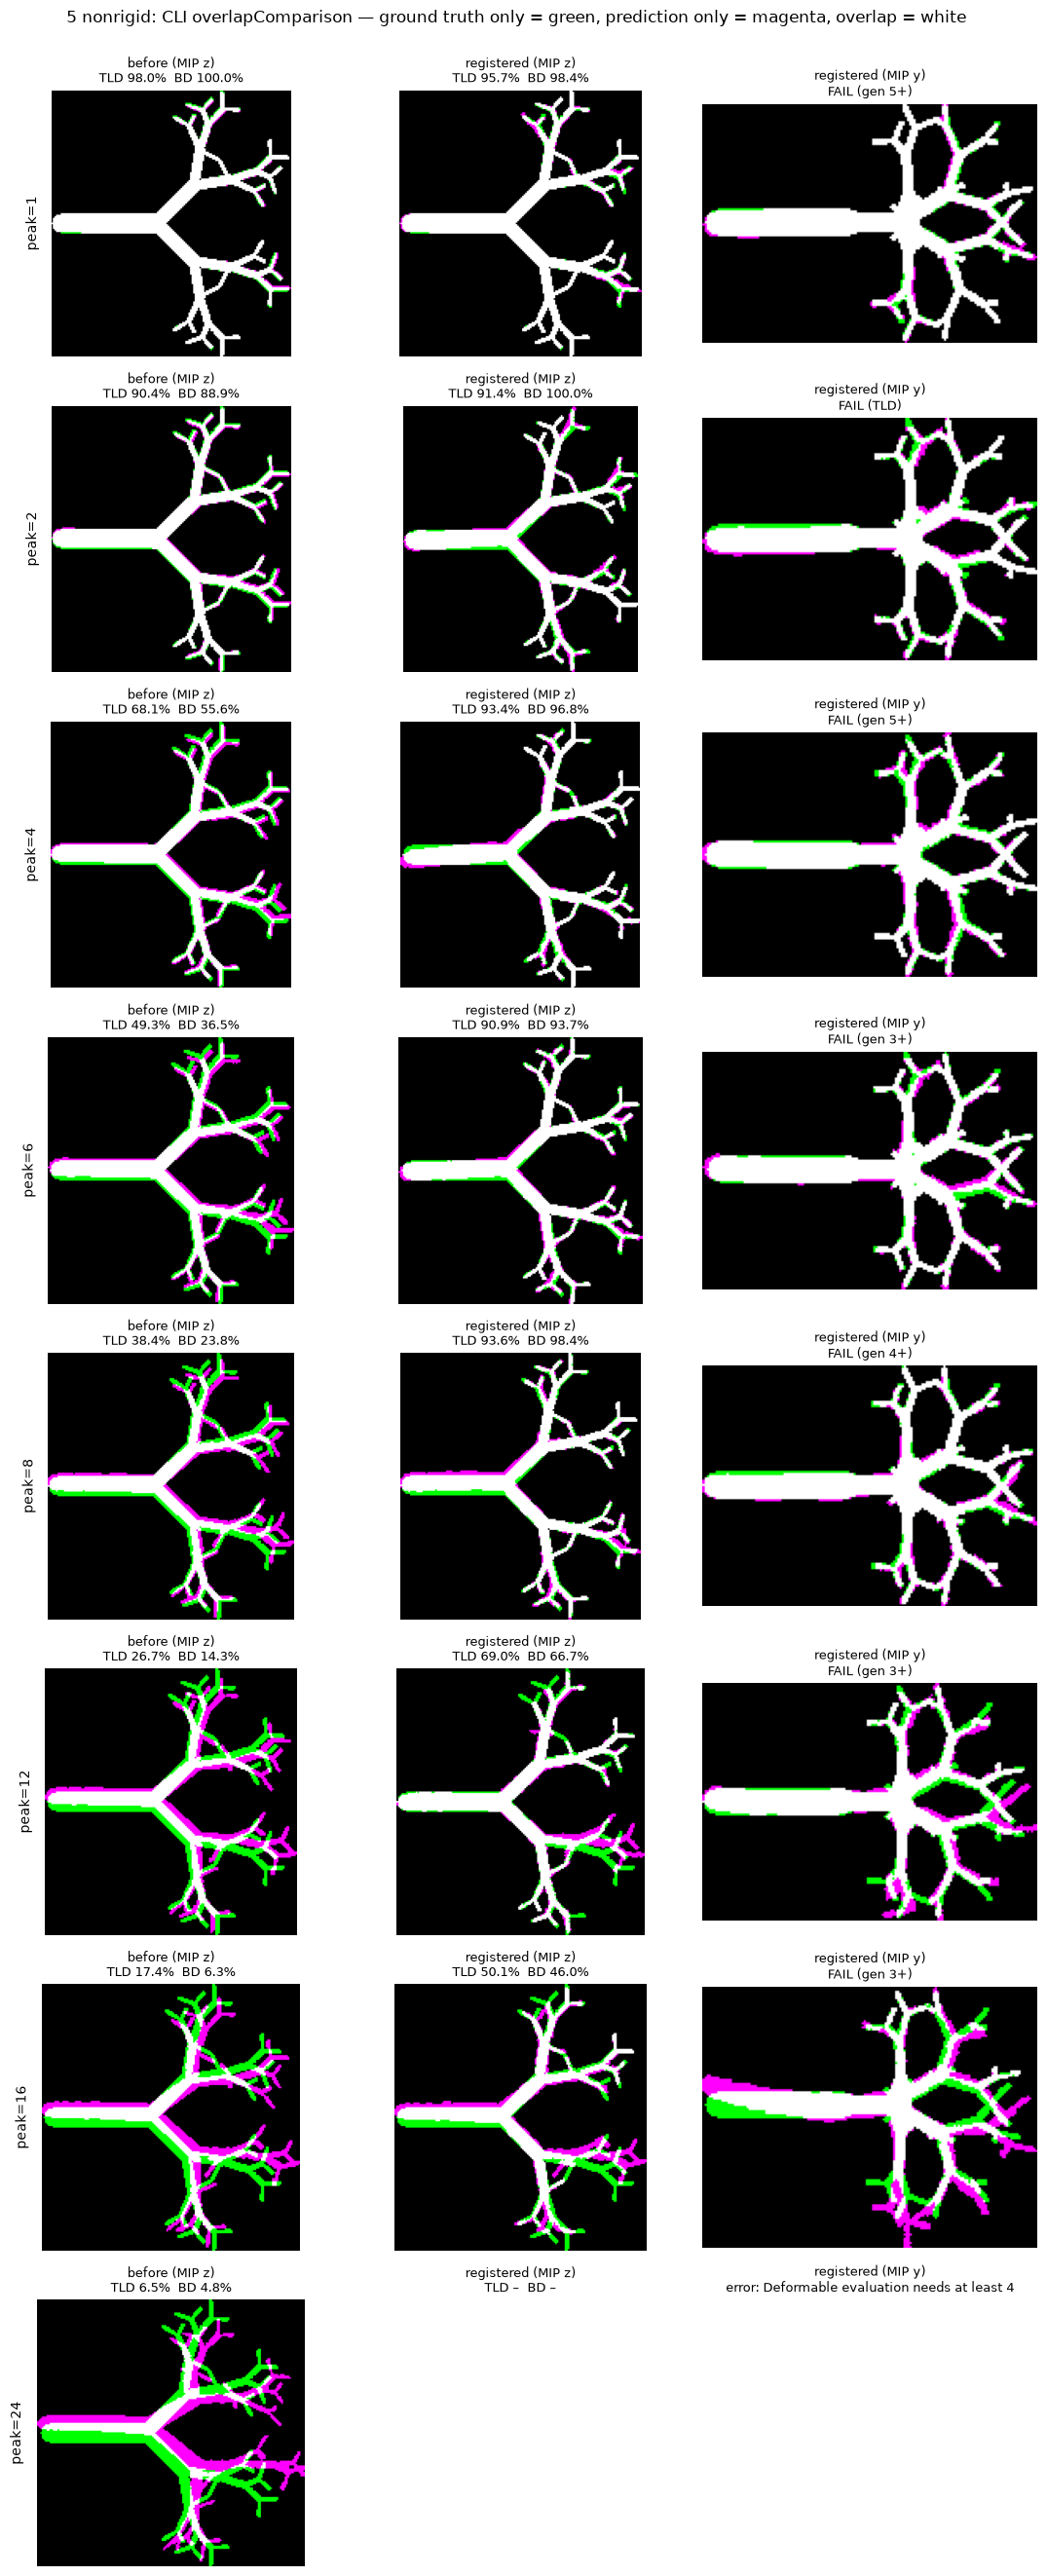

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
peak=1,"peak disp=1 vox, mesh=6",1.00,98.0%,95.7%,100.0%,98.4%,1/1,2/2,4/4,8/8,16/16,31/32,FAIL (gen 5+)
peak=2,"peak disp=2 vox, mesh=6",2.00,90.4%,91.4%,88.9%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,FAIL (TLD)
peak=4,"peak disp=4 vox, mesh=6",4.00,68.1%,93.4%,55.6%,96.8%,1/1,2/2,4/4,8/8,16/16,30/32,FAIL (gen 5+)
peak=6,"peak disp=6 vox, mesh=6",6.00,49.3%,90.9%,36.5%,93.7%,1/1,2/2,4/4,7/8,15/16,30/32,FAIL (gen 3+)
peak=8,"peak disp=8 vox, mesh=6",8.00,38.4%,93.6%,23.8%,98.4%,1/1,2/2,4/4,8/8,15/16,32/32,FAIL (gen 4+)
peak=12,"peak disp=12 vox, mesh=6",12.00,26.7%,69.0%,14.3%,66.7%,1/1,2/2,4/4,6/8,10/16,19/32,FAIL (gen 3+)
peak=16,"peak disp=16 vox, mesh=6",16.00,17.4%,50.1%,6.3%,46.0%,1/1,2/2,4/4,5/8,6/16,11/32,FAIL (gen 3+)
peak=24,"peak disp=24 vox, mesh=6",24.00,6.5%,–,4.8%,–,–,–,–,–,–,–,ERROR


In [10]:
magnitudes = [1, 2, 4, 6, 8, 12, 16, 24]

run_group("5 nonrigid", [
    (f"peak={m}", bspline(m), f"peak disp={m} vox, mesh=6")
    for m in magnitudes
])

## 6. Breath hold (nonterminal shift)
Mimics two CT acquisitions at different breath holds: the nonterminal tree is stretched craniocaudally (most at the
bases) and expanded laterally / anteroposteriorly, while each terminal branch keeps its shape and is carried along by
its origin. `cc` is the displacement of the deepest point as a fraction of the tree's depth (~150 voxels); a
10% difference is ~15 voxels at the bases, in the range of a partial vs full inspiration. Reported displacements are
over centerline points.

                       cc=2%: TLD 80.6% -> 95.1%  BD 76.2% -> 100.0% (63/63)  PASS  (6s)


                       cc=5%: TLD 39.6% -> 93.4%  BD 25.4% -> 96.8% (61/63)  FAIL (gen 5+)  (7s)


                      cc=10%: TLD 21.3% -> 94.7%  BD 9.5% -> 98.4% (62/63)  FAIL (gen 5+)  (8s)


                      cc=15%: TLD 18.0% -> 91.7%  BD 6.3% -> 98.4% (62/63)  FAIL (gen 5+)  (7s)


                      cc=20%: TLD 14.6% -> 89.6%  BD 6.3% -> 96.8% (61/63)  FAIL (gen 4+)  (7s)


                      cc=30%: error: Deformable evaluation needs at least 4 paired landmarks for the thin-plate spline, found 2


                 cc=10% asym: TLD 21.6% -> 91.7%  BD 11.1% -> 96.8% (61/63)  FAIL (gen 5+)  (7s)


               cc=10% +shift: TLD 2.5% -> 94.7%  BD 0.0% -> 98.4% (62/63)  FAIL (gen 5+)  (7s)


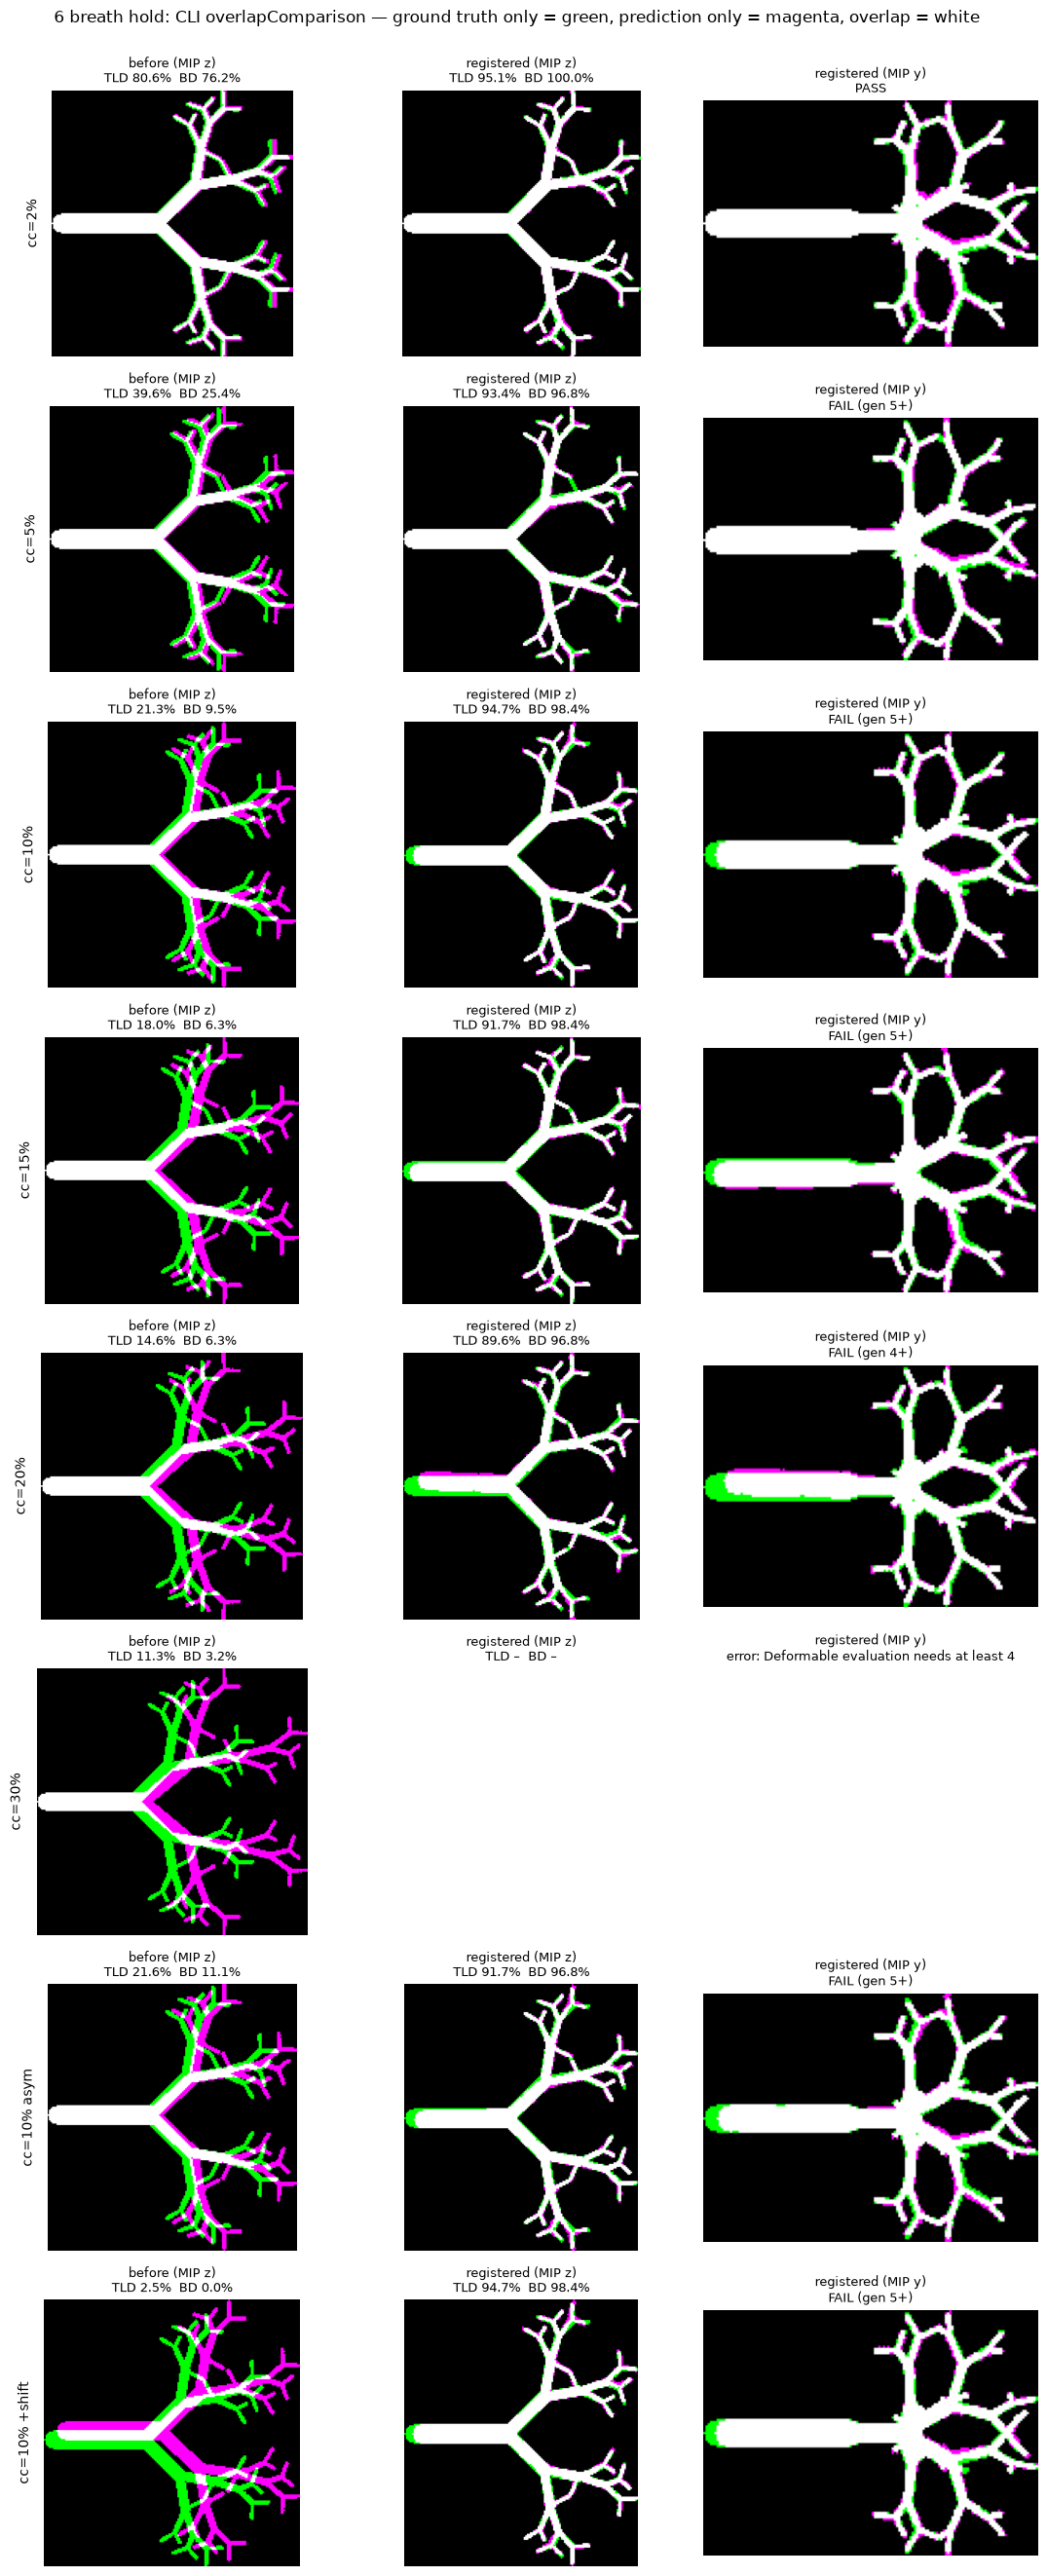

,parameters,peak disp,TLD before,TLD,BD before,BD,g0 det,g1 det,g2 det,g3 det,g4 det,g5 det,verdict
case,,,,,,,,,,,,,
cc=2%,cc=2% lat=1% ap=1%,2.49,80.6%,95.1%,76.2%,100.0%,1/1,2/2,4/4,8/8,16/16,32/32,PASS
cc=5%,cc=5% lat=2% ap=2%,6.22,39.6%,93.4%,25.4%,96.8%,1/1,2/2,4/4,8/8,16/16,30/32,FAIL (gen 5+)
cc=10%,cc=10% lat=5% ap=3%,12.45,21.3%,94.7%,9.5%,98.4%,1/1,2/2,4/4,8/8,16/16,31/32,FAIL (gen 5+)
cc=15%,cc=15% lat=8% ap=4%,18.67,18.0%,91.7%,6.3%,98.4%,1/1,2/2,4/4,8/8,16/16,31/32,FAIL (gen 5+)
cc=20%,cc=20% lat=10% ap=6%,24.90,14.6%,89.6%,6.3%,96.8%,1/1,2/2,4/4,8/8,15/16,31/32,FAIL (gen 4+)
cc=30%,cc=30% lat=15% ap=9%,37.34,11.3%,–,3.2%,–,–,–,–,–,–,–,ERROR
cc=10% asym,cc=10% lat=5% ap=3% asym=0.5,12.64,21.6%,91.7%,11.1%,96.8%,1/1,2/2,4/4,8/8,16/16,30/32,FAIL (gen 5+)
cc=10% +shift,"cc=10% lat=5% ap=3% shift=(8, -6, 4)",22.09,2.5%,94.7%,0.0%,98.4%,1/1,2/2,4/4,8/8,16/16,31/32,FAIL (gen 5+)


In [11]:
breath_holds = [BreathHold(cc) for cc in (0.02, 0.05, 0.10, 0.15, 0.20, 0.30)] + [
    BreathHold(0.10, asymmetry=0.5),
    BreathHold(0.10, shift=(8, -6, 4)),
]

run_group("6 breath hold", [(bh.name, bh, bh.describe()) for bh in breath_holds])

## Results

**Summary**: one row per case. `verdict` is PASS when TLD ≥ `PERFECT_TLD` and every generation's branch detection is
≥ `PERFECT_GEN_BD`; otherwise it names the first generation that loses a branch (or `FAIL (TLD)` when every branch is
detected but tree length is short). `DSC` is kept for reference only; `outputs` is the case's CLI output directory.

In [12]:
results = pd.DataFrame(list(RESULTS.values())).set_index(["group", "case"])
results.to_csv("deformation_stress_results.csv")

summary_columns = [
    "parameters", "mean disp", "peak disp", "moving/fixed vox", "TLD before", "TLD", "BD before", "BD",
    "branches", "DSC", "seconds", "status", "verdict", "outputs",
]
(results.reindex(columns=summary_columns)
    .style.format(precision=2, na_rep="–")
    .format("{:.1%}", subset=PERCENT_COLUMNS, na_rep="–")
    .map(highlight_verdict, subset=["verdict"])
    .map(lambda v: highlight_below(v, PERFECT_TLD), subset=["TLD"])
    .map(lambda v: highlight_below(v, 1.0), subset=["BD"]))

**Per generation**: branch detection (fraction of the generation's ground truth branches detected) and the detected
counts, with TLD alongside.

In [13]:
generation_labels = [f"gen {g}" for g in GEN_IDS]
per_generation = pd.concat(
    {
        "BD": results.reindex(columns=[f"g{g} BD" for g in GEN_IDS]).set_axis(generation_labels, axis=1),
        "detected": results.reindex(columns=GEN_DET_COLUMNS).set_axis(generation_labels, axis=1),
    },
    axis=1,
)
per_generation[("TLD", "")] = results["TLD"]
per_generation[("verdict", "")] = results["verdict"]

bd_columns = [c for c in per_generation.columns if c[0] == "BD"]
(per_generation.style.format("{:.0%}", subset=bd_columns, na_rep="–")
    .format("{:.1%}", subset=[("TLD", "")], na_rep="–")
    .map(lambda v: highlight_below(v, PERFECT_GEN_BD), subset=bd_columns)
    .map(lambda v: highlight_below(v, PERFECT_TLD), subset=[("TLD", "")])
    .map(highlight_detection, subset=[c for c in per_generation.columns if c[0] == "detected"])
    .map(highlight_verdict, subset=[("verdict", "")]))

**Where it breaks**: for each group, the largest deformation that still reconstructs ~perfectly and the first one
that doesn't. The chart shows per-generation branch detection and TLD for every case, so you can see which
generations drop first.

,passed,last PASS before first failure,first failure,failure mode
group,,,,
0 identity,1/1,identity,–,–
1 translation,7/7,"t=(45, 30, -30)",–,–
2 rotation,2/8,"r=(0, 10, 0)","r=(0, 0, 15)",FAIL (gen 4+)
3 translation+rotation,0/6,–,"r=(5, 5, 0) t=(3, -3, 2)",FAIL (TLD)
4 translation+rotation+shear,0/6,–,"r=(5, 0, 5) t=(3, -3, 2) s=(0.02, 0.0, 0.0)",FAIL (gen 4+)
5 nonrigid,0/8,–,peak=1,FAIL (gen 5+)
6 breath hold,1/8,cc=2%,cc=5%,FAIL (gen 5+)


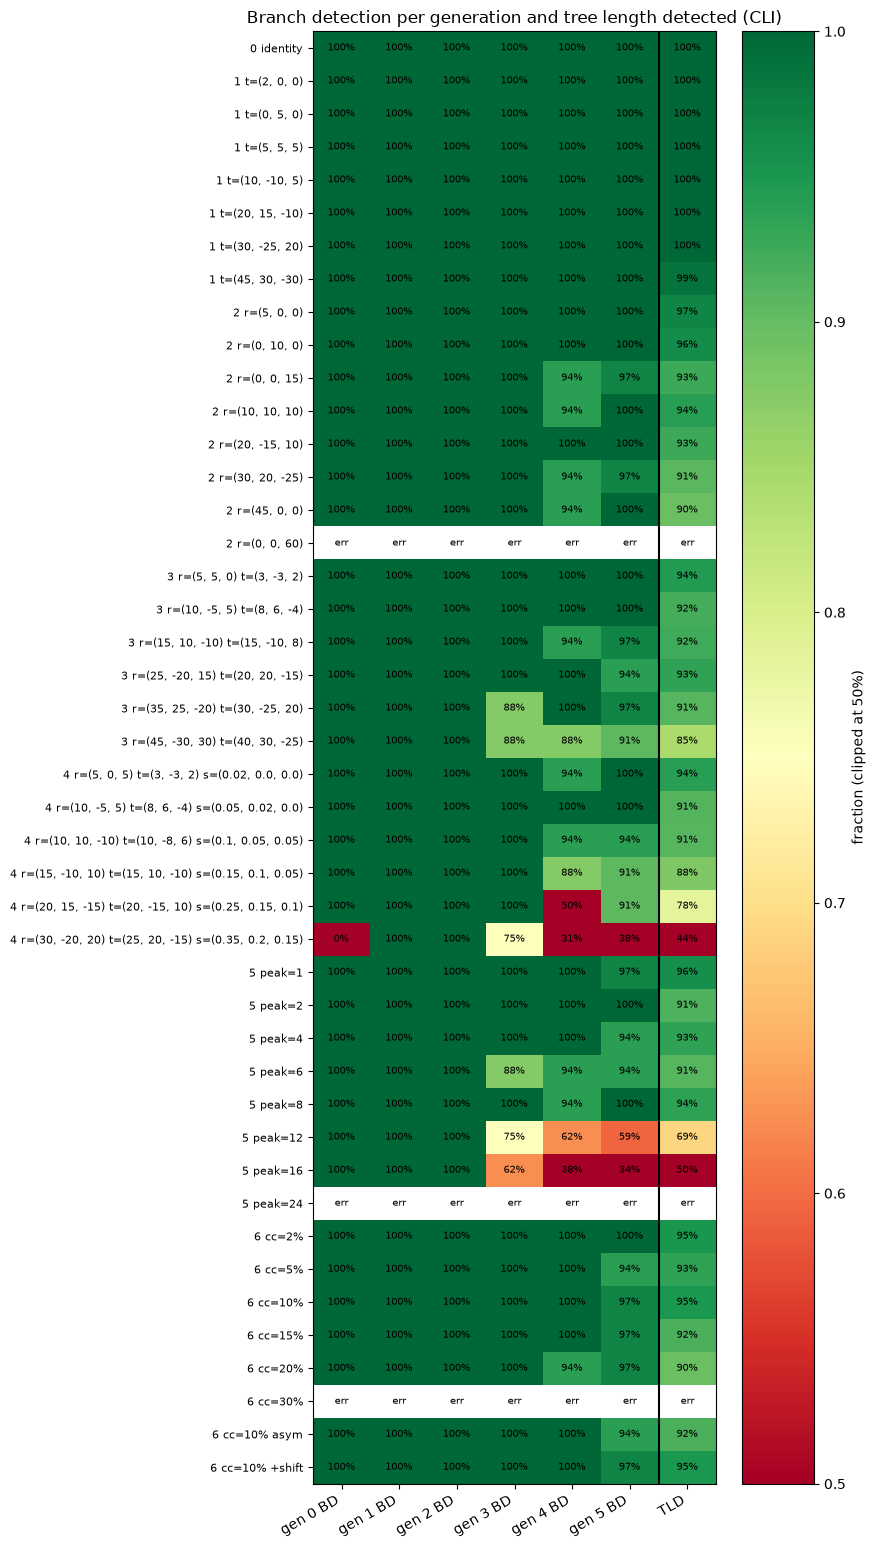

In [14]:
breakdown = []
for group, rows in results.groupby(level="group", sort=False):
    verdicts = rows["verdict"].tolist()
    cases = rows.index.get_level_values("case").tolist()
    first_fail = next((i for i, v in enumerate(verdicts) if v != "PASS"), None)
    breakdown.append({
        "group": group,
        "passed": f"{verdicts.count('PASS')}/{len(cases)}",
        "last PASS before first failure": (
            cases[-1] if first_fail is None else cases[first_fail - 1] if first_fail > 0 else "–"),
        "first failure": "–" if first_fail is None else cases[first_fail],
        "failure mode": "–" if first_fail is None else verdicts[first_fail],
    })
display(pd.DataFrame(breakdown).set_index("group"))

score_matrix = results.reindex(columns=[f"g{g} BD" for g in GEN_IDS] + ["TLD"]).astype(float)
fig, ax = plt.subplots(figsize=(8.5, 0.32 * len(score_matrix) + 1.5))
image = ax.imshow(score_matrix.values, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
ax.axvline(len(GEN_IDS) - 0.5, color="black", linewidth=1.5)
ax.set_xticks(range(len(GEN_IDS) + 1), [f"gen {g} BD" for g in GEN_IDS] + ["TLD"], rotation=30, ha="right")
ax.set_yticks(range(len(score_matrix)), [f"{g[:2]}{c}" for g, c in score_matrix.index], fontsize=8)
for (i, j), value in np.ndenumerate(score_matrix.values):
    ax.text(j, i, "err" if np.isnan(value) else f"{value:.0%}", ha="center", va="center", fontsize=7)
fig.colorbar(image, ax=ax, label="fraction (clipped at 50%)")
ax.set_title("Branch detection per generation and tree length detected (CLI)")
plt.tight_layout()
plt.show()

## Debug volumes of the worst case

The lowest-TLD case that still ran, drawn from the CLI's own debug volumes: the overlap comparison, the tree length
comparison (prediction mask = 1, ground truth skeleton over it = 2), and the ground truth vs registered prediction
generation labels. Change `DEBUG_CASE` to look at any other `(group, case)`.

DEBUG_CASE = ('4 translation+rotation+shear', 'r=(30, -20, 20) t=(25, 20, -15) s=(0.35, 0.2, 0.15)') TLD 43.5% -> cli_outputs/4_translation+rotation+shear/r=_30_-20_20_t=_25_20_-15_s=_0.35_0.2_0.15


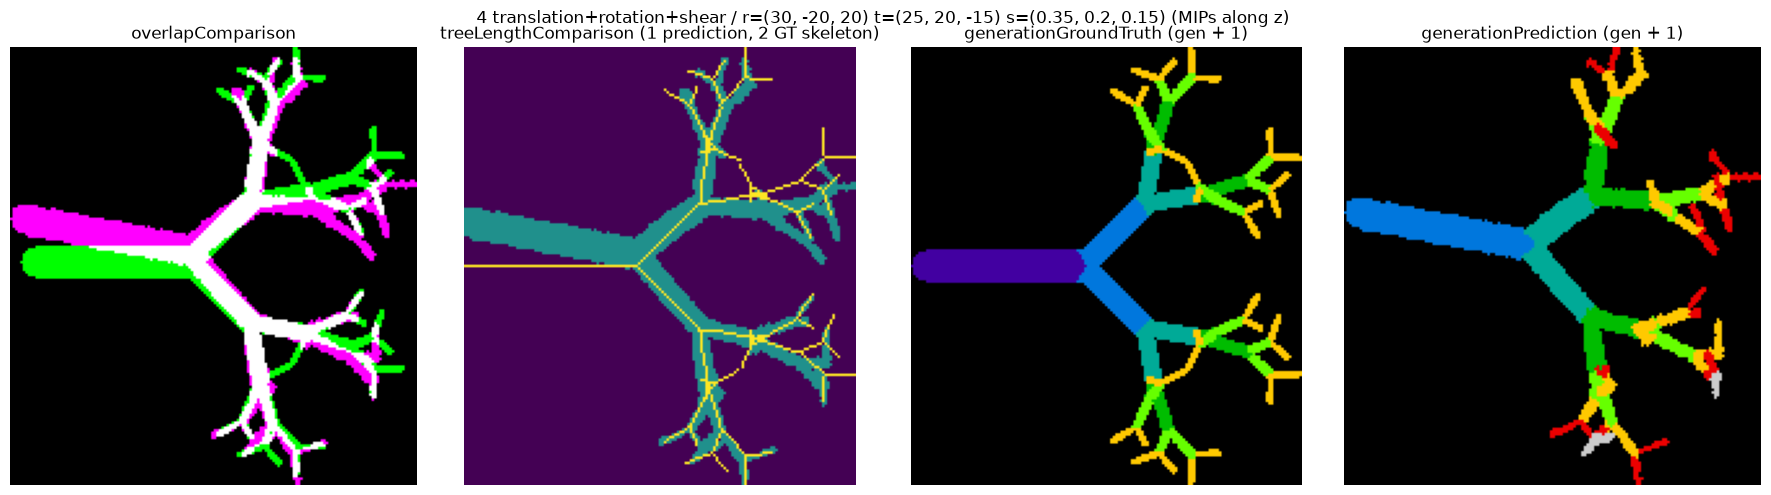

files: ['branchOrigins.csv', 'generationGroundTruth.nii.gz', 'generationPrediction.nii.gz', 'groundTruthSkeleton.nii.gz', 'labeledGroundTruth.nii.gz', 'labeledPrediction.nii.gz', 'log.txt', 'overlapComparison.nii.gz', 'predictionSkeleton.nii.gz', 'registeredPrediction.nii.gz', 'results.csv', 'treeLengthComparison.nii.gz']


In [15]:
ok = results[results["status"] == "ok"]
DEBUG_CASE = ok["TLD"].astype(float).idxmin()
print("DEBUG_CASE =", DEBUG_CASE, f"TLD {ok.loc[DEBUG_CASE, 'TLD']:.1%}", "->", RESULTS[DEBUG_CASE]["outputs"])


def show_debug(key):
    registered = RUNS[key][1]
    tree_length = itk.array_view_from_image(registered.volume("treeLengthComparison"))
    generation_truth = itk.array_view_from_image(registered.volume("generationGroundTruth"))
    generation_prediction = itk.array_view_from_image(registered.volume("generationPrediction"))

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(overlap_mip(registered, 0))
    axes[0].set_title("overlapComparison")
    axes[1].imshow(tree_length.max(axis=0), cmap="viridis")
    axes[1].set_title("treeLengthComparison (1 prediction, 2 GT skeleton)")
    vmax = max(generation_truth.max(), generation_prediction.max())
    axes[2].imshow(generation_truth.max(axis=0), cmap="nipy_spectral", vmin=0, vmax=vmax)
    axes[2].set_title("generationGroundTruth (gen + 1)")
    axes[3].imshow(generation_prediction.max(axis=0), cmap="nipy_spectral", vmin=0, vmax=vmax)
    axes[3].set_title("generationPrediction (gen + 1)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{key[0]} / {key[1]} (MIPs along z)")
    plt.tight_layout()
    plt.show()
    print("files:", sorted(os.listdir(registered.out_dir)))


show_debug(DEBUG_CASE)

## Hyperparameter sweep

The sweep over deformations x trees x CLI hyperparameters is `DeformationSweep.py` (results in `sweep_results/`),
analyzed in `DeformationSweepReport.ipynb`. To try one setting here, edit `PARAMETERS` in the configuration cell and
re-run.

## Why the phantom is non-planar

With `PLANE_TWIST = 0` every landmark lies in one plane, so the thin plate spline's affine part is undetermined and
even pure translations come back wrong although every landmark pairs perfectly. This section keeps that evidence: the
same pure translations, in-plane (y) and out-of-plane (z), scored by the CLI on a planar tree and on the non-planar
tree used above.

--- planar: 58 branches, extent x/y/z = [151 170  12]


                        y=10: TLD 22.2% -> 100.0%  BD 9.1% -> 100.0% (55/55)  PASS  (2s)


                        y=20: TLD 16.0% -> 100.0%  BD 10.9% -> 100.0% (55/55)  PASS  (2s)


                        y=30: TLD 11.7% -> 100.0%  BD 5.5% -> 100.0% (55/55)  PASS  (2s)


                        y=45: TLD 17.3% -> 99.0%  BD 14.6% -> 100.0% (55/55)  PASS  (2s)


...

                        z=10: TLD 4.8% -> 100.0%  BD 1.6% -> 100.0% (63/63)  PASS  (6s)


                        z=20: TLD 2.7% -> 100.0%  BD 1.6% -> 100.0% (63/63)  PASS  (6s)


                        z=30: TLD 2.1% -> 100.0%  BD 1.6% -> 100.0% (63/63)  PASS  (6s)


                        z=45: TLD 0.2% -> 100.0%  BD 0.0% -> 100.0% (63/63)  PASS  (6s)


               (30, -25, 20): TLD 0.4% -> 100.0%  BD 0.0% -> 100.0% (63/63)  PASS  (6s)


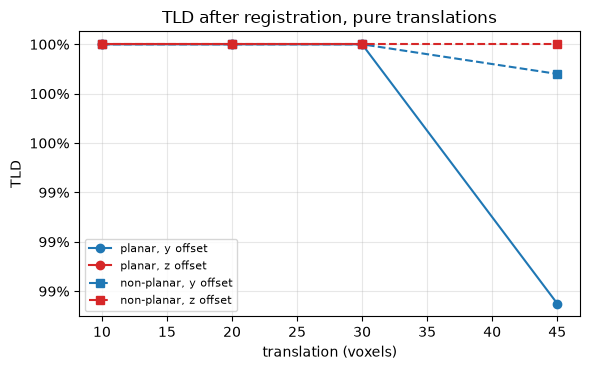

In [16]:
planar_airway = make_synthetic_airway(
    image_size=IMAGE_SIZE, generations=GENERATIONS, bifurcation_angle=BIFURCATION_ANGLE, plane_twist=0
)
PHANTOMS = {"planar": planar_airway, "non-planar": base_airway}

PLANE_CASES = (
    [(f"y={m}", (0, m, 0)) for m in (10, 20, 30, 45)]
    + [(f"z={m}", (0, 0, m)) for m in (10, 20, 30, 45)]
    + [("(30, -25, 20)", (30, -25, 20))]
)

PLANE_RESULTS = {}
PLANE_RUNS = {}
try:
    for name, tree in PHANTOMS.items():
        set_phantom(tree, name)
        print(f"--- {name}: {len(tree.branches)} branches, extent x/y/z = {np.ptp(np.argwhere(fixed_array), axis=0)[::-1]}")
        for case, offset in PLANE_CASES:
            run_case(name, case, translation(offset), f"t={offset}", results=PLANE_RESULTS, runs=PLANE_RUNS,
                     root=os.path.join(OUTPUT_DIR, "planar_vs_nonplanar"))
finally:
    set_phantom(base_airway, "non-planar")

plane_results = pd.DataFrame(list(PLANE_RESULTS.values())).set_index(["group", "case"])
side_by_side = pd.concat(
    {metric: plane_results[metric].unstack(0)[list(PHANTOMS)] for metric in ["TLD", "BD"]}, axis=1
).reindex([c for c, _ in PLANE_CASES])
display(side_by_side.style.format("{:.1%}", na_rep="error"))

fig, ax = plt.subplots(figsize=(6, 3.8))
for name, style in zip(PHANTOMS, ["o-", "s--"]):
    for axis, color in [("y", "#1f77b4"), ("z", "#d62728")]:
        cases = [c for c, _ in PLANE_CASES if c.startswith(axis + "=")]
        ax.plot([int(c[2:]) for c in cases], side_by_side.loc[cases, ("TLD", name)], style,
                color=color, label=f"{name}, {axis} offset")
ax.set_xlabel("translation (voxels)")
ax.set_ylabel("TLD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
ax.set_title("TLD after registration, pure translations")
plt.tight_layout()
plt.show()